In [1]:
def getDist(cord1,cord2):
	return (
		(float(cord1[0])-float(cord2[0]))**2+
		(float(cord1[1])-float(cord2[1]))**2+
		(float(cord1[2])-float(cord2[2]))**2)**0.5 * 10

class gro:    # ndx = {chineID : (start atomNdx, end atomNdx)}
    def __init__(self, groFile):
        from tqdm import tqdm
        self.version = "groObj V.1"
        self.type = "Multi Chains"
        with open(groFile, "r") as gro:
            groLines = gro.readlines()
            self.atomNum = groLines[1]
        self.frames = {} # { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
        frameNdx = 0
        atomDic = {}
        resNdx = groLines[2].split()[:-3]
        for line in tqdm(groLines[2:]):
            line_list = line.split()
            if len(line_list) == 3:
                self.frames[frameNdx] = atomDic
                frameNdx = frameNdx + 1
                atomDic = {}
            elif "Title" not in line and len(line.split()) > 3:
                #print(line)
                atomNdx = int(line.split()[2])
                atomDic[atomNdx] = {
                    "resNdx" : int(line.split()[0][:-3]),
                    "coord" : (
                        float(line.split()[3]),
                        float(line.split()[4]),
                        float(line.split()[5])
                    )
                }
    def getRes(self, ndx):
      frameDic = {} # { frameNdx : { resNdx : { atomNdx : (coord) } } }
      for frame in self.frames.items():# { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
          frameNdx = frame[0]
          atomDic = frame[1]
          resDic = {}
          for atomNdx in range(ndx[0], ndx[1]+1):
              resNdx = atomDic[atomNdx]["resNdx"]
              coord = atomDic[atomNdx]["coord"]
              if resNdx not in list(resDic.keys()):
                  resDic[resNdx] = [coord]
              else:
                  resDic[resNdx].append(coord)
          frameDic[frameNdx] = resDic
      return frameDic

def contactPerFrame(frameNdx, proAtomNdx, ligAtomNdx, groObj):
    import pandas as pd
    import pickle
    with open(groObj, "rb") as groDataFile:
        groData = pickle.load(groDataFile)
    ligRes = groData.getRes(ligAtomNdx)[frameNdx]
    proRes = groData.getRes(proAtomNdx)[frameNdx]
    #print(proRes[15])
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    #print(distDic)
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame


In [2]:
groData = gro("../3_md/md.fit.gro")
import pickle
with open("groData.pkl", "wb") as groDataFile:
    pickle.dump(groData, groDataFile)

100%|██████████| 2941937/2941937 [00:18<00:00, 155663.59it/s]


In [ ]:
# import pickle as pkl
# with open("groData.pkl", "rb") as groDataFile:
#     groData = pkl.load(groDataFile)

In [3]:
frameNdx = 0
proAtomNdx = (1, 2863)
ligAtomNdx = (2864, 2936)
contactPerFrame(frameNdx, proAtomNdx, ligAtomNdx, "groData.pkl")

,15,16,17,18,19,20,21,22,23,24,...,185,186,187,188,189,190,191,192,193,frameNdx
0,14.583,13.6,11.07,6.499,3.643,9.554,9.885,3.598,6.807,2.631,...,10.644,2.477,9.897,7.926,11.843,15.748,13.946,9.733,12.82,0


In [4]:
import pickle
import pandas as pd
from tqdm import tqdm
#print("> loading data")
#with open("groData.pkl", "rb") as groDataFile:
#    groData = pickle.load(groDataFile)
#print("> loaded data")
#for item in groData.frames[1000][15].items():
#    print(item)
from joblib import Parallel, delayed
print("> joblib imported")
proAtomNdx = (1, 2863)
ligAtomNdx = (2864, 2936)
print("> startting multiProcessing")
results = Parallel(
    n_jobs=64, backend='multiprocessing'
    )(delayed(contactPerFrame)(frameNdx, proAtomNdx, ligAtomNdx, "groData.pkl") for frameNdx in tqdm(range(0,1001)))
print("> multiProcessing done")
results = pd.concat(results, axis=0, ignore_index=True)
results = results.sort_values(by=results.columns[-1], ascending=True)
with open("con_results.pkl", "wb") as con_results:
    pickle.dump(results, con_results)
print("> done")

> joblib imported
> startting multiProcessing


100%|██████████| 1001/1001 [12:44<00:00,  1.31it/s]


> multiProcessing done
> done


In [5]:
import pickle
import pandas as pd
with open("con_results.pkl", "rb") as con_results:
    results = pickle.load(con_results)
(results)

,15,16,17,18,19,20,21,22,23,24,...,185,186,187,188,189,190,191,192,193,frameNdx
0,14.583,13.600,11.070,6.499,3.643,9.554,9.885,3.598,6.807,2.631,...,10.644,2.477,9.897,7.926,11.843,15.748,13.946,9.733,12.820,0
1,16.452,14.978,11.559,7.913,5.344,10.315,11.326,5.439,7.071,2.156,...,11.588,3.326,10.105,11.167,11.459,15.493,13.845,9.931,16.008,1
2,16.618,15.351,11.906,8.111,5.156,10.514,10.149,4.229,5.667,2.731,...,10.322,2.684,9.798,9.890,13.012,16.989,16.895,11.877,14.416,2
3,15.239,15.238,11.368,8.741,3.957,9.887,9.871,5.212,6.276,2.349,...,11.047,2.726,10.756,10.927,13.962,18.335,17.516,12.670,16.881,3
4,16.293,15.445,12.810,9.139,5.309,10.395,9.969,3.821,5.240,2.460,...,10.169,2.093,9.783,10.892,13.916,18.099,17.112,13.283,15.826,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,7.030,9.646,7.537,3.589,3.442,6.558,6.930,2.784,6.866,2.708,...,11.524,6.519,13.178,9.057,13.310,12.151,17.936,19.237,17.721,996
997,7.605,9.186,6.792,3.525,2.643,5.339,6.172,2.570,6.104,2.250,...,11.994,6.692,13.568,9.201,14.243,7.801,16.136,15.625,11.410,997
998,9.023,10.327,8.024,5.111,3.324,6.053,6.720,2.819,5.575,2.394,...,11.918,6.809,12.821,9.157,13.560,8.300,15.694,16.313,13.211,998
999,7.324,8.604,6.134,2.819,2.289,5.319,5.803,2.710,6.292,2.384,...,10.967,6.212,12.476,8.593,13.684,9.168,17.122,20.338,15.433,999


In [6]:
heatDat = results.iloc[:, :-1].T
heatDat

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
15,14.583,16.452,16.618,15.239,16.293,17.139,16.968,16.006,16.154,12.641,...,6.043,6.401,6.751,6.757,8.121,7.030,7.605,9.023,7.324,6.859
16,13.600,14.978,15.351,15.238,15.445,15.553,15.091,14.671,14.662,12.828,...,8.225,8.673,8.107,8.654,9.434,9.646,9.186,10.327,8.604,8.868
17,11.070,11.559,11.906,11.368,12.810,12.215,12.099,12.415,12.259,10.405,...,6.327,6.795,6.348,6.963,7.494,7.537,6.792,8.024,6.134,6.924
18,6.499,7.913,8.111,8.741,9.139,8.857,9.091,8.235,8.242,5.667,...,2.741,2.700,2.669,3.040,3.601,3.589,3.525,5.111,2.819,3.104
19,3.643,5.344,5.156,3.957,5.309,4.625,4.314,5.294,4.421,4.888,...,2.663,2.348,2.897,2.764,3.143,3.442,2.643,3.324,2.289,2.968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,11.843,11.459,13.012,13.962,13.916,13.816,13.721,13.813,13.802,13.375,...,13.540,14.213,15.294,13.193,14.011,13.310,14.243,13.560,13.684,13.863
190,15.748,15.493,16.989,18.335,18.099,16.788,16.445,17.001,15.018,14.056,...,15.942,16.074,11.780,16.042,13.951,12.151,7.801,8.300,9.168,9.846
191,13.946,13.845,16.895,17.516,17.112,16.411,16.567,14.812,16.749,15.309,...,17.283,16.609,18.097,18.590,18.429,17.936,16.136,15.694,17.122,18.328
192,9.733,9.931,11.877,12.670,13.283,12.314,12.276,11.616,12.049,11.310,...,16.598,14.876,18.026,21.285,19.779,19.237,15.625,16.313,20.338,21.787


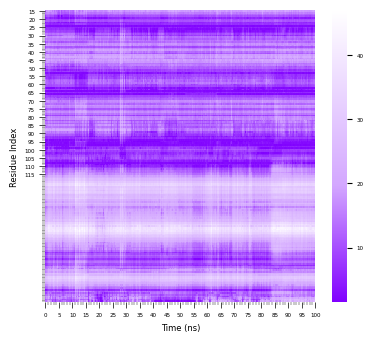

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

df = pd.DataFrame(heatDat)

# 创建自定义颜色映射
# 5以下颜色越小越深，大于等于5的白色
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#8000FF"), (0.4, "#D3A7FF"), (1, "#ffffff")],
    N=512
)
#norm = mcolors.Normalize(vmin=0, vmax=5)
#cbar_kws={'ticks': []}

# 绘制热图
fig, ax = plt.subplots(figsize=(4, 3.5) )  # 设置图形大小
sns.heatmap(df, annot=False, cmap=cmap)#, norm=norm, fmt=".1f", cbar_kws=cbar_kws)  # 设置颜色条的标签
plt.yticks([x+0.5 for x in range(0, 101, 5)], range(15, 116, 5))
plt.xticks([x for x in range(0,1001,50)],[ x for x in range(0,101,5)],rotation=0)
ax.tick_params(axis="y",reset=True, which="both", direction="out", width=0.5, length=4,labelsize=4,right=False)
ax.tick_params(axis="y", which="minor",reset=True, direction="out", width=0.3, length=2,zorder=1,right=False)
ax.tick_params(axis="x", which="major", direction="out", width=0.5, length=4, right=False,labelsize=4)
ax.tick_params(axis="x", which="minor", direction="out", width=0.3, length=2, right=False)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
#for i in range(0, 100, 1):
#    ax.axhline(i, color='grey',linewidth=0.1)
    #ax2.axvline(i, color='black',linewidth=0.2)

#plt.text(1115, 17,'d > 5Å', fontsize=4, rotation=-90)
#plt.text(1115, 46,'5Å ≥ d > 4Å', fontsize=4, rotation=-90)
#plt.text(1115, 71,'4Å ≥ d > 3Å', fontsize=4, rotation=-90)
#plt.text(1115, 92,'3Å ≥ d', fontsize=4, rotation=-90)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4)  # 设置颜色条刻度的字体大小

plt.tight_layout(pad=1.5)
plt.ylabel("Residue Index", fontsize=6)
plt.xlabel("Time (ns)", fontsize=6)
plt.savefig("HeatMap_PAC5_100_2.png", dpi=600)
plt.savefig("HeatMap_PAC5_100_2.svg", dpi=600)
plt.show()


In [17]:
heatDat.iloc[0:101,:]

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
15,14.583,18.717,18.786,18.367,19.024,19.542,18.671,18.485,18.956,18.940,...,18.542,17.841,19.219,18.344,18.446,18.982,18.684,19.602,18.779,19.210
16,13.600,15.897,16.616,15.952,16.575,16.551,15.916,16.620,15.890,16.868,...,15.124,15.090,16.500,15.597,15.284,15.750,15.728,16.546,15.216,15.876
17,11.070,13.781,13.678,13.544,13.861,14.027,13.696,13.857,13.185,13.651,...,12.480,12.203,13.566,12.852,12.666,13.023,12.731,13.497,12.586,13.112
18,6.499,11.703,10.942,10.895,10.832,11.669,11.443,11.064,10.974,11.180,...,9.984,9.711,11.017,10.046,10.615,10.231,10.080,10.667,9.761,10.702
19,3.643,6.377,5.356,6.172,6.446,7.142,7.327,7.310,7.804,7.088,...,4.495,4.802,5.819,5.026,5.236,4.794,4.635,4.665,4.916,4.560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,5.068,5.536,6.290,6.972,7.261,7.372,8.593,8.350,8.519,11.611,...,10.422,11.111,12.110,11.557,11.685,11.295,10.975,11.013,11.998,11.570
112,8.729,8.811,10.207,10.675,10.967,11.162,12.241,12.319,12.348,15.134,...,14.321,14.868,15.902,15.275,15.348,15.121,14.750,14.931,15.747,15.385
113,9.572,9.647,10.490,11.736,11.618,11.604,12.947,13.233,13.501,16.131,...,15.033,15.590,16.245,15.889,15.327,15.556,15.362,14.837,16.035,15.614
114,10.346,10.802,11.917,12.129,12.213,11.386,12.405,13.591,14.159,15.400,...,14.724,13.946,14.865,14.992,14.159,14.542,14.238,13.944,14.535,14.907


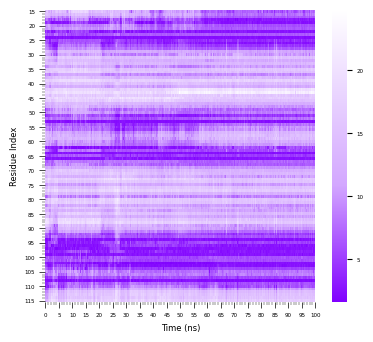

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

df = pd.DataFrame(heatDat.iloc[0:101,:])

# 创建自定义颜色映射
# 5以下颜色越小越深，大于等于5的白色
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#8000FF"), (0.4, "#D3A7FF"), (1, "#ffffff")],
    N=512
)
#norm = mcolors.Normalize(vmin=0, vmax=5)
#cbar_kws={'ticks': []}

# 绘制热图
fig, ax = plt.subplots(figsize=(4, 3.5) )  # 设置图形大小
sns.heatmap(df, annot=False, cmap=cmap)#, norm=norm, fmt=".1f", cbar_kws=cbar_kws)  # 设置颜色条的标签
plt.yticks([x+0.5 for x in range(0, 101, 5)], range(15, 116, 5))
plt.xticks([x for x in range(0,1001,50)],[ x for x in range(0,101,5)],rotation=0)
ax.tick_params(axis="y",reset=True, which="both", direction="out", width=0.5, length=4,labelsize=4,right=False)
ax.tick_params(axis="y", which="minor",reset=True, direction="out", width=0.3, length=2,zorder=1,right=False)
ax.tick_params(axis="x", which="major", direction="out", width=0.5, length=4, right=False,labelsize=4)
ax.tick_params(axis="x", which="minor", direction="out", width=0.3, length=2, right=False)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
#for i in range(0, 100, 1):
#    ax.axhline(i, color='grey',linewidth=0.1)
    #ax2.axvline(i, color='black',linewidth=0.2)

#plt.text(1115, 17,'d > 5Å', fontsize=4, rotation=-90)
#plt.text(1115, 46,'5Å ≥ d > 4Å', fontsize=4, rotation=-90)
#plt.text(1115, 71,'4Å ≥ d > 3Å', fontsize=4, rotation=-90)
#plt.text(1115, 92,'3Å ≥ d', fontsize=4, rotation=-90)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4)  # 设置颜色条刻度的字体大小

plt.tight_layout(pad=1.5)
plt.ylabel("Residue Index", fontsize=6)
plt.xlabel("Time (ns)", fontsize=6)
plt.savefig("HeatMap_PAC5_2.png", dpi=600)
plt.savefig("HeatMap_PAC5_2.svg", dpi=600)
plt.show()
